In [41]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

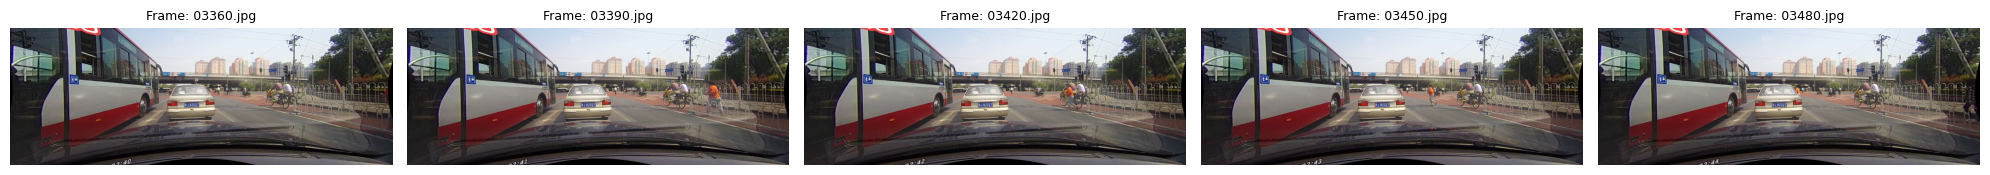

In [42]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path


base_dir = Path.cwd().parent
data_dir = base_dir / "Data"

train_img_path = data_dir / "driver_37_30frame"/"driver_37_30frame"/ "05191020_0411.MP4"

# 1. Get all files and sort them to maintain the time sequence

all_images = sorted([
    p for p in os.listdir(train_img_path) 
    if p.endswith(('.jpg', '.png', '.jpeg')) and ".lines" not in p
])

# 2. Select a random starting index for a continuous block of 5
if len(all_images) >= 5:
    start_idx = random.randint(0, len(all_images) - 5)
    test_images = all_images[start_idx : start_idx + 5]
else:
    test_images = all_images
    print(f"Note: Only {len(all_images)} images available.")

# Save the sequence to JSON
with open("test_images.json", "w") as f:
    json.dump(test_images, f)

# 3. Plotting the sequence
plt.figure(figsize=(20, 5))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    # Displaying the filename so you can verify they are sequential
    plt.title(f"Frame: {img_name}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

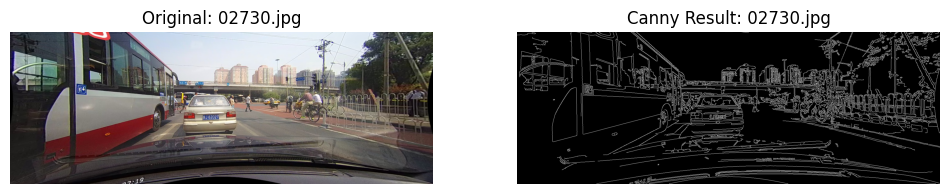

Saved raw edge image to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Canny_Edge_Results\02730_canny_only.jpg


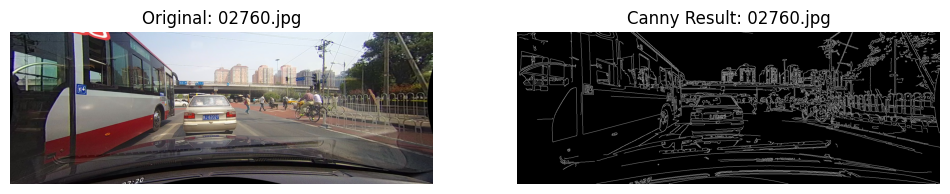

Saved raw edge image to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Canny_Edge_Results\02760_canny_only.jpg


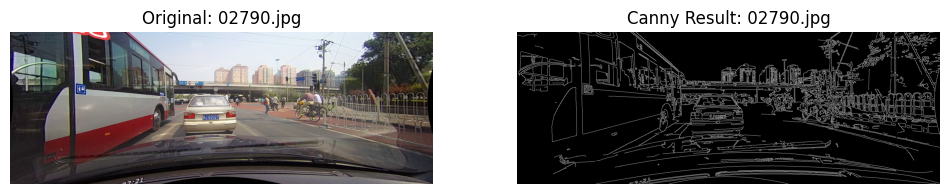

Saved raw edge image to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Canny_Edge_Results\02790_canny_only.jpg


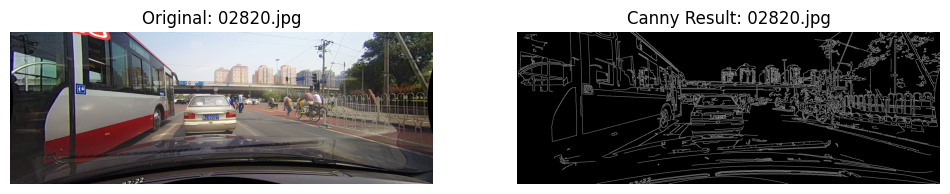

Saved raw edge image to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Canny_Edge_Results\02820_canny_only.jpg


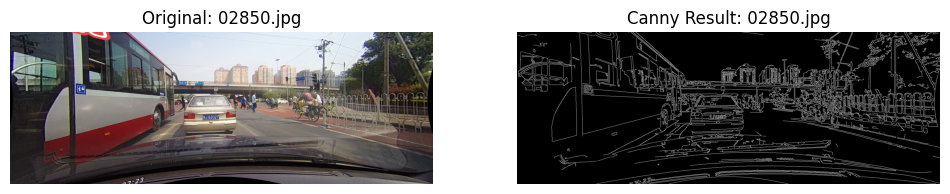

Saved raw edge image to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Canny_Edge_Results\02850_canny_only.jpg


In [43]:
import os
import random
import json
import matplotlib.pyplot as plt
import cv2
import numpy as np 
from pathlib import Path

# Setup paths
base_dir = Path.cwd().parent
data_dir = base_dir / "Data"
train_img_path = data_dir / "driver_37_30frame" / "driver_37_30frame" / "05191020_0411.MP4"

# Create results directory for PNGs
Canny_Edge_Folder = Path.cwd().parent / "Notebooks" / "Canny_Edge_Results"

# Clear output folder
for p in Canny_Edge_Folder.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(Canny_Edge_Folder, exist_ok=True)


# 1. Get and sort images
all_images = sorted([
    p for p in os.listdir(train_img_path) 
    if p.endswith(('.jpg', '.png', '.jpeg')) and ".lines" not in p
])

# 2. Select sequence of 5
if len(all_images) >= 5:
    start_idx = random.randint(0, len(all_images) - 5)
    test_images = all_images[start_idx : start_idx + 5]
else:
    test_images = all_images

# 3. Process, Display, and Save
for img_name in test_images:
    img_full_path = os.path.join(train_img_path, img_name)
    
    # Load and process
    img_bgr = cv2.imread(img_full_path)
    if img_bgr is None: continue
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Canny Logic
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    
    # --- SAVE ONLY THE CANNY IMAGE ---
    # We use cv2.imwrite to save just the raw edge data (no plot borders/titles)
    save_name = Path(img_name).stem + "_canny_only.jpg"
    save_path = Canny_Edge_Folder / save_name
    cv2.imwrite(str(save_path), edges)
    
    # --- DISPLAY SIDE-BY-SIDE IN NOTEBOOK ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.imshow(img_rgb)
    ax1.set_title(f"Original: {img_name}")
    ax1.axis('off')
    
    ax2.imshow(edges, cmap='gray')
    ax2.set_title(f"Canny Result: {img_name}")
    ax2.axis('off')
    
    plt.show() # This prints them out in your console/notebook
    print(f"Saved raw edge image to: {save_path}")

# Save the sequence list to JSON
with open(Canny_Edge_Folder / "test_images.json", "w") as f:
    json.dump(test_images, f)